# Projector KZ approximations

This is for trying to predict the form of the time evolved expectaiton values $\braket{P_n(\tau)}$. the so-called "Golden Goose" is put to test here.

REally, a few more things need to be done here to make good progress. 

In [1]:
import sys
sys.path.append("../../src/")
import kibble_zurek as kz
import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter, loglog, xlim, ylim, xlabel, ylabel, loglog, show,legend,yscale,xscale
from time import time
from scipy.optimize import curve_fit

In [2]:
nmax = 20
Ntaus = 50
data_file_name = f"Data/KZ_data_nmax={nmax}_NTaus=_{Ntaus}.npz"

raw_data = np.load(data_file_name)


In [3]:
nmax = 20
Ntaus = 50
data_file_name = f"Data/KZ_data_nmax={nmax}_NTaus=_{Ntaus}.npz"

raw_data = np.load(data_file_name)
KZ_array,taus,n_values = raw_data["KZ_Array"],raw_data["taus"],raw_data["n_values"]


In [ ]:
plot(taus,(1/2-KZ_array.T))
loglog()

ValueError: operands could not be broadcast together with shapes (50,18) (50,) 

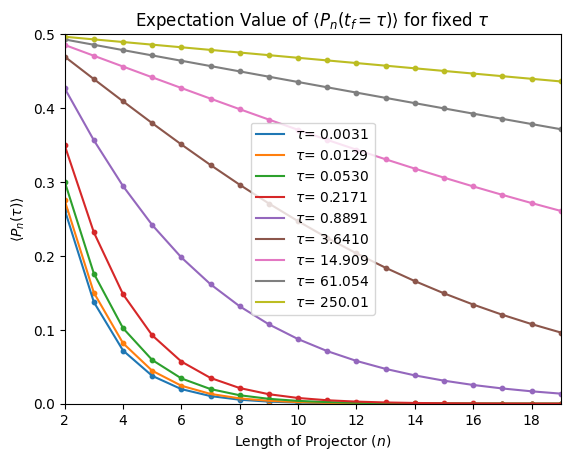

In [197]:
for i in range(0,Ntaus,6):
    plot(n_values,KZ_array[:,i],label=rf"$\tau$= {str(taus[i])[:6]}")
    scatter(n_values,KZ_array[:,i],s=10)

xlim(n_values[0],n_values[-1])
legend()
xlabel(r"Length of Projector ($n$)")
ylabel(r"$\langle P_n (\tau) \rangle$")
plt.title(r"Expectation Value of $\langle P_n (t_f=\tau) \rangle$ for fixed $\tau$")
#yscale("log")
ylim(0,.5)
plt.savefig("Expectation_value_vs_n_and_tau.pdf")

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9798/971340800.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_model, x, y, p0=(1,1,1))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9798/971340800.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9798/971340800.py:26: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ylim(0,.5)


(np.float64(2.453648846122696e-06), 0.5)

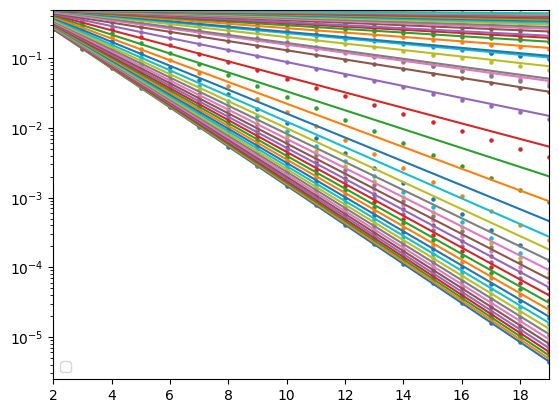

In [310]:

def exp_model(x, lam,A,B):
    return  (A+x*B*0)*2**(-lam * (x))

lam_list= []
A_list= []
B_list=[]
for i in range(0,len(taus),1):
    # Example data
    x = np.array(n_values)
    y =KZ_array[:,i]
    # Fit
    popt, pcov = curve_fit(exp_model, x, y, p0=(1,1,1))
    lam_fit,A_fit,B_fit = popt
    lam_list.append(lam_fit)
    A_list.append(A_fit)
    B_list.append(B_fit)
    plt.scatter(x,y,s=5)
    plt.plot(x,exp_model(x,lam_fit,A_fit,B_fit))
    j=i
    #plot(n_values,(1+2*p[j])/2*(1-p[j])**(n_values),ls=":",color="black")

xlim(n_values[0],n_values[-1])

plt.legend()
yscale("log")
ylim(0,.5)


In [311]:
def G(n):
    data =[]
    for s in states:
        data.append(kz.G(n,s))
    return np.array(data)

a, b, mu, sigma = [ 0.04603369  1.35648934 -0.00467885]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_9798/4092858542.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(model, x, y, p0=[1, 1, 1])


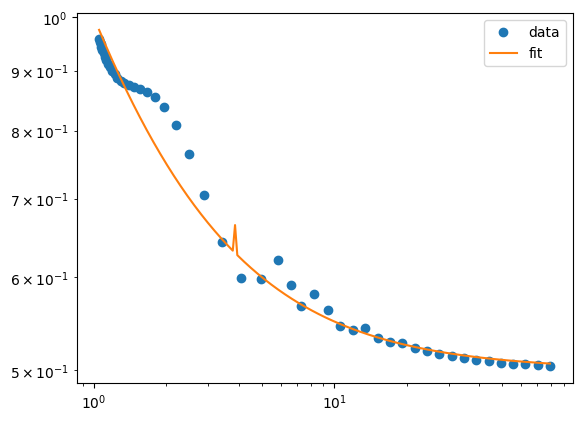

In [360]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# model
def model(x, b, mu, sigma):
    return 0.5 + 0.5/x + b * np.exp(-((np.log(x) - mu)**2) / (2*sigma**2))

# fake example data (replace with yours)
x = corr
y = A_list

# fit
popt, _ = curve_fit(model, x, y, p0=[1, 1, 1])
print("a, b, mu, sigma =", popt)

# plot
plt.loglog(x, y, 'o', label="data")
xx = np.logspace(np.log10(min(x)), np.log10(max(x)), 200)
plt.loglog(xx, model(xx, *popt), '-', label="fit")
plt.legend()
plt.show()


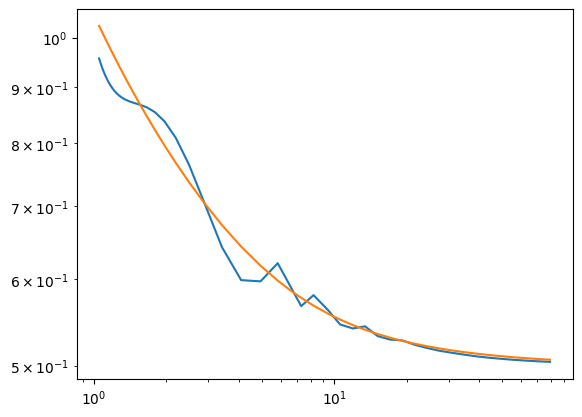

In [376]:
plot(corr,A_list)
plot(corr,model(corr,.05,0.1,1))
xscale("log")
yscale("log")

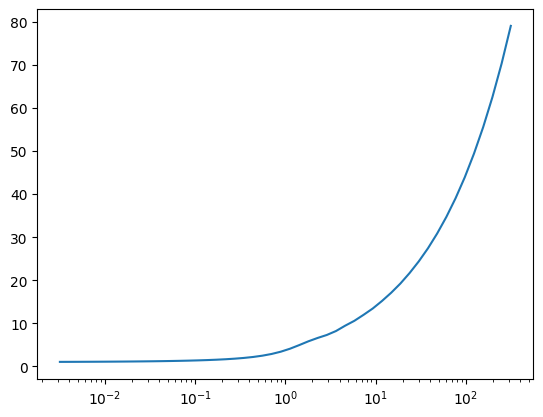

In [ ]:
corr = 1/(2*rho)


def dumb_model(corr,A,B):
    
xscale("log")
plot(taus,corr)

In [322]:
sqrt(taus[-1])

np.float64(17.78279410038923)

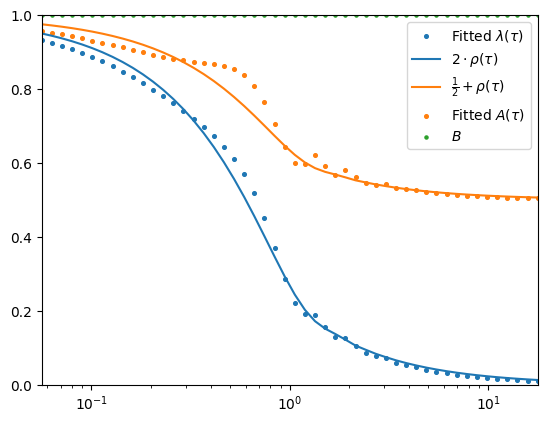

In [349]:
rho = 1/2*(1-ss1)
plt.scatter(np.sqrt(taus), lam_list, s=7, label=r"Fitted $ \lambda(\tau)$")
plot(np.sqrt(taus), 2*rho, label=r"$2 \cdot \rho(\tau)$")
plot(np.sqrt(taus), 1/2+rho, label=r"$\frac{1}{2}+\rho(\tau)$")
plt.scatter(np.sqrt(taus), A_list, s=7, label=r"Fitted $A(\tau)$")
scatter(np.sqrt(taus), B_list, s=5, label=r"$B$")
plt.xlim(np.sqrt(taus[0]), np.sqrt(taus[-1]))
plt.ylim(0,1)
xscale("log")
legend()


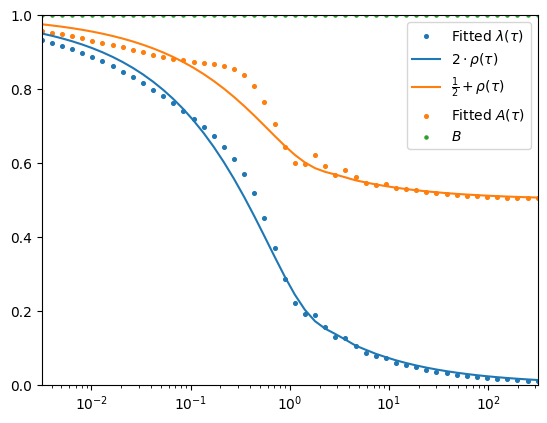

In [318]:
rho = 1/2*(1-ss1)
plt.scatter(taus,lam_list,s=7,label=r"Fitted $ \lambda(\tau)$")
plot(taus,2*rho,label=r"$2 \cdot \rho(\tau)$")
plot(taus,1/2+rho,label=r"$\frac{1}{2}+\rho(\tau)$")
plt.scatter(taus,A_list,s=7,label=r"Fitted $A(\tau)$")
scatter(taus,B_list,s=5,label=r"$B$")


plt.xlim(taus[0],taus[-1])
plt.ylim(0,1)
xscale("log")
legend()

In [244]:
L = 1024

states=[]
for tau in taus:
    state = kz.state(L,tau,tau)
    states.append(state)

In [ ]:
n=-
G0=[]
G1=[]
G2=[]
GN=[]
P3 = []

ss1=[]
ss2=[]
for s in states:
    G0.append(kz.G(0,s))
    G1.append(kz.G(1,s))
    G2.append(kz.G(2,s))
    GN.append(kz.G(n,s))
    P3.append(kz.P_n(3,s))
    ss1.append(kz.sigma_general([0,1],s))
    ss2.append(kz.sigma_general([0,2],s))

ss1=np.array(ss1)
ss2=np.array(ss2)
P3=np.array(P3)
G0=np.array(G0)
G1=np.array(G1)
G2=np.array(G2)

/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/AUG17_KZ_investigation_PLEASESORT/../../src/kibble_zurek.py:170: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


In [35]:
kz.G(1,states[15])

np.complex128(0.2852836755249865-0j)

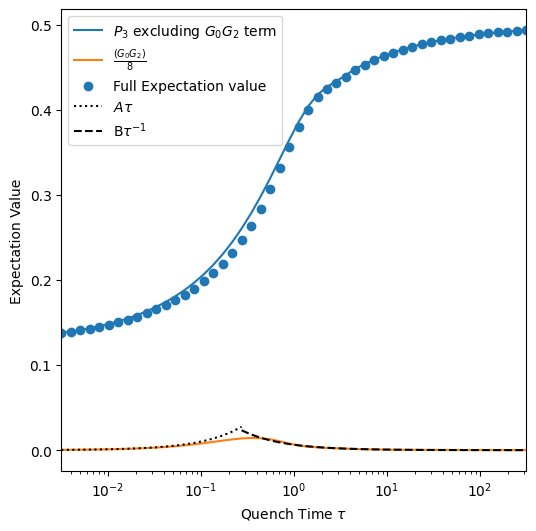

In [92]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(taus,1/8*(1+2*G1+G1**2),label=r"$P_3$ excluding $G_0G_2$ term")
ax.plot(taus,1/8*(G0*G2),label=r"$\frac{(G_0 G_2)}{8}$")
ax.scatter(taus,P3,label="Full Expectation value")
ax.set_xlim(taus[0],taus[-1])
ax.set_xlabel(r"Quench Time $\tau$")
ax.set_ylabel(r"Expectation Value")
ax.set_xscale("log")
#ax.set_yscale("log")
ax.plot(taus[:20],taus[:20]/10,color="black",ls=":",label=r"$A \tau$")
ax.plot(taus[19:],taus[19:]**(-1)/taus[3]**(-1),color="black",ls="--",label=r"B$\tau^{-1}$")
ax.legend()


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


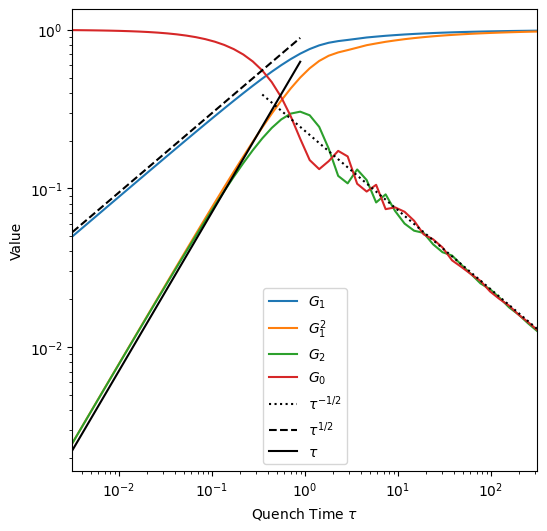

In [238]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(taus,G1,label=r"$G_1$")
ax.plot(taus,G1*G1,label=r"$G_1^2$")
ax.plot(taus,G2,label=r"$G_2$")
ax.plot(taus,G0,label=r"$G_0$")
#ax.plot(taus,G0*G2,label=r"$G_0 G_2$")


ax.set_xlim(taus[0],taus[-1])
ax.set_xlabel(r"Quench Time $\tau$")
ax.set_ylabel(r"Value")
ax.set_xscale("log")
ax.set_yscale("log")

ax.plot(taus[20:],taus[20:]**(-1/2)/taus[12]**(-1/2),color="black",ls=":",label=r"$\tau^{-1/2}$")
#ax.plot(taus[20:],taus[20:]**(-1)/taus[12]**(-1),color="black",ls="-.",label=r"$\tau^{-1}$")
ax.plot(taus[:25],taus[:25]**(1/2)/taus[25]**(1/2),color="black",ls="--",label=r"$\tau^{1/2}$")
ax.plot(taus[:25],taus[:25]**(1)/sqrt(2),color="black",ls="-",label=r"$\tau$")

ax.legend()


# $P_4$

In [ ]:
Gm2=[]
Gm1=[]
G0=[]
G1=[]
G2=[]
G3=[]
P4 = []

ss1=[]
ss2=[]
ss3=[]
ssn=[]
s4= []
for s in states:
    Gm2.append(kz.G(-1,s))
    Gm1.append(kz.G(-1,s))
    G0.append(kz.G(0,s))
    G1.append(kz.G(1,s))
    G2.append(kz.G(2,s))
    G3.append(kz.G(3,s))
    P4.append(kz.P_n(4,s))
    ss1.append(kz.sigma_general([0,1],s))
    ss2.append(kz.sigma_general([0,2],s))
    ss3.append(kz.sigma_general([0,3],s))
    ssn.append(kz.sigma_general([0,6],s))

    s4.append(kz.sigma_general([0,1,2,3],s))


ss1=np.array(ss1)
ss2=np.array(ss2)
ss3=np.array(ss3)
ssn=np.array(ssn)
s4 =np.array(s4)
P4=np.array(P4)
Gm1=np.array(Gm1)
G0=np.array(G0)
G1=np.array(G1)
G2=np.array(G2)
G3=np.array(G3)


/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/AUG17_KZ_investigation_PLEASESORT/../../src/kibble_zurek.py:170: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


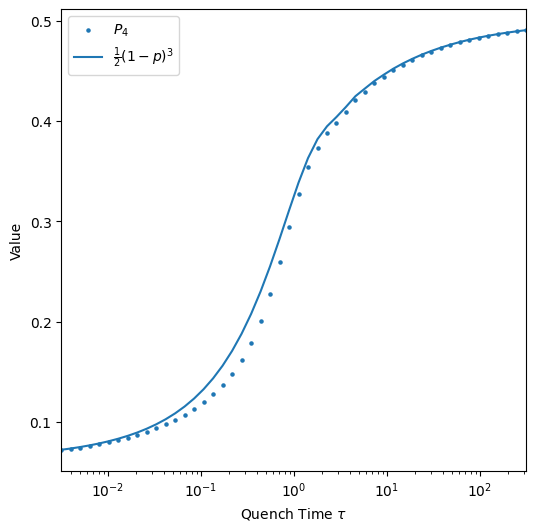

In [187]:
fig, ax = plt.subplots(figsize=(6,6))
#####
#Sigmas
#####
# ax.plot(taus,ss1,label=r"$\sigma_0\sigma_1$")
# ax.plot(taus,ss2,label=r"$\sigma_0\sigma_2$")
# ax.plot(taus,ss3,label=r"$\sigma_0\sigma_3$")
#ax.plot(taus,ssn,label=r"$\sigma_0\sigma_n$")
#ax.plot(taus,s4,label=r"$\sigma_0\sigma_1\sigma_2\sigma_3$")
#ax.plot(taus,G0*G2,label=r"$G_0 G_2$")

###########
#Convergence
###########

term1= G1
term2 = G1**2#-G0*G2
term3= G1**3#+G0**2*G3+G2**2*Gm1 - 2*G0*G1*G2-G1*G3*Gm1
term4= G1*G1#-G3*Gm1

ax.scatter(taus,P4,label=r"$P_4$",s=5)
ax.plot(taus,abs(2**(-4)*(1+3*term1+2*term2+term3+term4)),label=r"$\frac{1}{2}(1-p)^3$")
ax.set_xlim(taus[0],taus[-1])
ax.set_xlabel(r"Quench Time $\tau$")
ax.set_ylabel(r"Value")
ax.set_xscale("log")
#ax.set_yscale("log")

ax.legend()


Text(0, 0.5, 'Expectation Value')

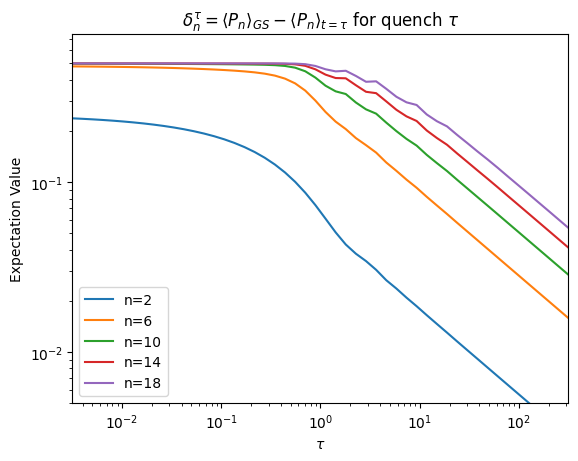

In [70]:
for i, d in enumerate((1/2-KZ_array)):
    if i %4==0:
        n = n_values[i]
        plot(taus,(d),label=f"n={n}")

loglog()
legend()
ylim(.005,.75)
xlim(taus[0],taus[-1])
plt.title(r"$\delta_n^\tau= \langle P_n \rangle _{GS} -\langle P_n \rangle_{t=\tau}$ for quench $\tau$")
xlabel(r"$\tau$")
ylabel(r"Expectation Value")

Text(0, 0.5, 'Expectation Value')

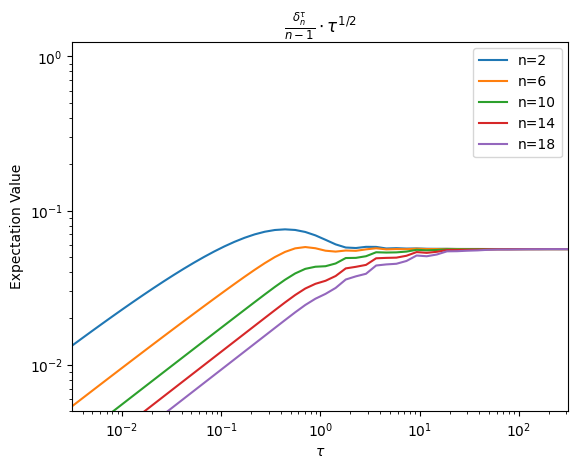

In [82]:
for i, d in enumerate((1/2-KZ_array)):
    if i %4==0:
        n = n_values[i]
        plot(taus,(d)*taus**(1/2)/(n-1),label=f"n={n}")

loglog()
legend()
ylim(.005,1.25)
xlim(taus[0],taus[-1])
plt.title(r"$\frac{\delta_n^\tau}{n-1} \cdot \tau^{1/2}$")
xlabel(r"$\tau$")
ylabel(r"Expectation Value")